In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv(override=True)
logging.langsmith("CH01-FEATURES")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH01-FEATURES


# State Manual Update 

- LangGraph은 중간 단계의 State를 수동으로 업데이트 할 수 있는 방안을 제공함 
- 이를 통해 에이전트 행동을 수정하여 경로를 제어할 수 있음 
- 또한 에이전트의 실수를 수정하거나, 대체 경로를 탐색하는 것처럼 특정 목표에 따라 에이전트의 동작을 변경할 때 유용함 

## Vanilla Agent 

In [2]:
from langchain_teddynote.tools.tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_teddynote.graphs import visualize_graph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated
from typing_extensions import TypedDict

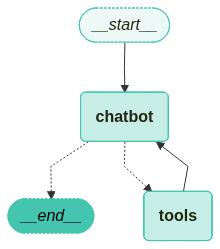

In [3]:
########## 1. 상태 정의 ##########
class State(TypedDict):
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
tool = TavilySearch(max_results=3)
tools = [tool]

llm = ChatOpenAI(model="gpt-4.1-nano")
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)


########## 4. 엣지 추가 ##########
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)


########## 5. 그래프 컴파일 ##########
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


########## 6. 그래프 시각화 ##########
visualize_graph(graph)

In [4]:
from langchain_core.runnables import RunnableConfig

In [5]:
question = "LangGraph 가 무엇인지 조사하여 알려주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# config 설정
config = RunnableConfig(
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

**channels**

- LangGraph 내부에서 노드 간 데이터가 흐르는 경로(통로) 
- 각 노드의 입력과 출력을 연결하는 데이터 이동 경로 

In [6]:
# 그래프 채널 목록 출력
list(graph.channels)

['messages',
 '__start__',
 '__pregel_tasks',
 'branch:to:chatbot',
 'branch:to:tools']

## 중단된 지점 찾기 (interrupt 상태 확인)

In [7]:
# 그래프 스트림 호출
events = graph.stream(
    input=input, config=config, interrupt_before=["tools"], stream_mode="values"
)

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_jE2qq1ggyZd6u36Nd2LxrkWd)
 Call ID: call_jE2qq1ggyZd6u36Nd2LxrkWd
  Args:
    query: LangGraph


In [8]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 가장 최근 메시지 추출
last_message = snapshot.values["messages"][-1]

# 메시지 출력
last_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_jE2qq1ggyZd6u36Nd2LxrkWd)
 Call ID: call_jE2qq1ggyZd6u36Nd2LxrkWd
  Args:
    query: LangGraph


## 도구 결과 수동 수정하기

- `TavilySearch` 도구에서 검색 결과 수정하여 새로운 ToolMessage 생성
- tool_call_id를 기존 메시지에서 추출 후 동일 ID로 새 메시지 생성
- 그래프 상태 업데이트 (graph.update_state)로 반영
- 이후 흐름 계속 실행

In [9]:
modified_search_result = """[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요."""

print(modified_search_result)

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


In [10]:
# 수정하고자 하는 `ToolMessage` 의 `tool_call_id` 추출
tool_call_id = last_message.tool_calls[0]["id"]
print(tool_call_id)

call_jE2qq1ggyZd6u36Nd2LxrkWd


**메시지 타입**

- HumanMessage : 사용자 입력 전달 
- AIMessage : LLM의 텍스트 응답 메시지, 일반적인 대화 응답 
- SystemMessage : 대화 설정 또는 시스템 프롬프트 
- ToolMessage : 도구 실행 결과 메시지

In [11]:
from langchain_core.messages import AIMessage, ToolMessage

In [12]:
new_messages = [
    # LLM API의 도구 호출과 일치하는 ToolMessage 필요
    ToolMessage(
        content=modified_search_result,
        tool_call_id=tool_call_id,
    ),
    # LLM의 응답에 직접적으로 내용 추가
    # AIMessage(content=modified_search_result),
]

new_messages[-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


## 수정된 상태 반영하기 (update_state)

**StateGraph의 `update_state`**

- `update_state` : 주어진 값으로 그래프의 상태를 업데이트
- 마치 `as_node`에서 값이 온 것처럼 동작함

**매개변수**

- `config` (RunnableConfig): 실행 구성
- `values` (Optional[Union[dict[str, Any], Any]]): 업데이트할 값들
- `as_node` (Optional[str]): 값의 출처로 간주할 노드 이름. 기본값은 None

**반환값**

- RunnableConfig

**주요 기능**

1. 체크포인터를 통해 이전 상태를 로드하고 새로운 상태를 저장
2. 서브그래프에 대한 상태 업데이트를 처리
3. `as_node`가 지정되지 않은 경우, 마지막으로 상태를 업데이트한 노드를 찾음
4. 지정된 노드의 writer들을 실행하여 상태를 업데이트
5. 업데이트된 상태를 체크포인트에 저장

**주요 로직**

1. 체크포인터를 확인하고, 없으면 ValueError를 발생시킴
2. 서브그래프에 대한 업데이트인 경우, 해당 서브그래프의 `update_state` 메서드를 호출
3. 이전 체크포인트를 로드하고, 필요한 경우 `as_node`를 결정
4. 지정된 노드의 writer들을 사용하여 상태를 업데이트
5. 업데이트된 상태를 새로운 체크포인트로 저장

**참고**

- 이 메서드는 그래프의 상태를 수동으로 업데이트할 때 사용
- 체크포인터를 사용하여 상태의 버전 관리와 지속성 보장
- `as_node`를 지정하지 않으면 자동으로 결정되지만, 모호한 경우 오류가 발생할 수 있음
- 상태 업데이트 중 SharedValues에 쓰기 작업은 허용되지 않음

In [13]:
graph.update_state(
    # 업데이트할 상태 지정
    config,
    # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
    {"messages": new_messages},
    as_node="tools",
)

print("(최근 1개의 메시지 출력)\n")
print(graph.get_state(config).values["messages"][-1])

(최근 1개의 메시지 출력)

content='[수정된 웹 검색 결과] \nLangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.\nLangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.\n\n자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과\n테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.' id='ca1d27c0-0a57-46de-a2d5-cd78b808b0fc' tool_call_id='call_jE2qq1ggyZd6u36Nd2LxrkWd'


In [14]:
snapshot = graph.get_state(config)
snapshot.next

('chatbot',)

In [15]:
events = graph.stream(None, config, stream_mode="values")

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM(대형 언어 모델)을 활용하여 구축할 수 있도록 지원하는 오픈 소스 라이브러리입니다. 이 라이브러리는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포와 같은 기능을 제공하며, 복잡한 애플리케이션의 개발을 용이하게 합니다. 자세한 내용과 튜토리얼은 [LangGraph 공식 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/)과 [테디노트의 한국어 튜토리얼](https://wikidocs.net/233785)을 참고하시면 됩니다.


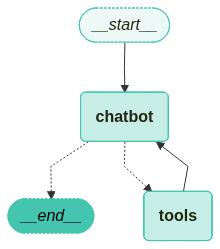

In [16]:
visualize_graph(graph)

In [17]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 최근 세 개의 메시지 출력
for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_jE2qq1ggyZd6u36Nd2LxrkWd)
 Call ID: call_jE2qq1ggyZd6u36Nd2LxrkWd
  Args:
    query: LangGraph
================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM(대형 언어 모델)을 활용하여 구축할 수 있도록 지원하는 오픈 소스 라이브러리입니다. 이 라이브러리는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포와 같은 기능을 제공하며, 복잡한 애플리케이션의 개발을 용이하게 합니다. 자세한 내용과 튜토리얼은 [LangGraph 공식 튜토리얼](https://langchain-ai.github.io/langg

In [18]:
# 다음 상태 출력
print(snapshot.next)

()


## 대화 메시지 직접 수정하기

- `TavilySearch` 도구에서 검색 쿼리 수정
- `thread_id` : 랜덤한 해시값을 생성하는 `generate_random_hash` 함수를 사용하여 적용 

In [19]:
from langchain_teddynote.graphs import generate_random_hash

thread_id = generate_random_hash()
print(f"thread_id: {thread_id}")

thread_id: f4c67d


In [20]:
question = "LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# 새로운 config 생성
config = {"configurable": {"thread_id": thread_id}}

events = graph.stream(
    input=input,
    config=config,
    interrupt_before=["tools"],
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_UC6AzIuLmAPcEI2oPmQaTgPf)
 Call ID: call_UC6AzIuLmAPcEI2oPmQaTgPf
  Args:
    query: LangGraph


In [21]:
# config 를 복사
config_copy = config.copy()

In [22]:
from langchain_core.messages import AIMessage

# 스냅샷 상태 
snapshot = graph.get_state(config)

# messages 의 마지막 메시지 
existing_message = snapshot.values["messages"][-1]

# 메시지 ID 출력
print("Message ID", existing_message.id)

Message ID lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0


In [23]:
# 첫 번째 도구 호출 출력
print(existing_message.tool_calls[0])

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph'}, 'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf', 'type': 'tool_call'}


In [24]:
# tool_calls 를 복사하여 새로운 도구 호출 생성
new_tool_call = existing_message.tool_calls[0].copy()

# 쿼리 매개변수 업데이트(갱신)
new_tool_call["args"] = {"query": "LangGraph Studio"}
new_tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph Studio'},
 'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf',
 'type': 'tool_call'}

In [25]:
# AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

print(new_message.id)

# 수정한 메시지 출력
new_message.pretty_print()

lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_UC6AzIuLmAPcEI2oPmQaTgPf)
 Call ID: call_UC6AzIuLmAPcEI2oPmQaTgPf
  Args:
    query: LangGraph Studio


In [26]:
# 업데이트된 도구 호출 출력
print(new_message.tool_calls[0])

# 메시지 ID 출력
print("\nMessage ID", new_message.id)

# 상태 업데이트
graph.update_state(config, {"messages": [new_message]})

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph Studio'}, 'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf', 'type': 'tool_call'}

Message ID lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0


{'configurable': {'thread_id': 'f4c67d',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11b5c1-05d0-6b9a-8002-c2f87f9b736f'}}

In [27]:
# 마지막 메시지의 도구 호출 가져오기
graph.get_state(config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph Studio'},
  'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf',
  'type': 'tool_call'}]

In [28]:
# 그래프 스트림에서 이벤트 수신
events = graph.stream(None, config, stream_mode="values")

# 각 이벤트에 대한 처리
for event in events:
    # 메시지가 있는 경우 마지막 메시지 출력
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_UC6AzIuLmAPcEI2oPmQaTgPf)
 Call ID: call_UC6AzIuLmAPcEI2oPmQaTgPf
  Args:
    query: LangGraph Studio
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://cobusgreyling.medium.com/langgraph-studio-from-langchain-4242d58b4bf4", "title": "LangGraph Studio From LangChain - Cobus Greyling - Medium", "content": "LangGraph Studio is a tool to observe, discover and inspect agent behaviour in detail. It allows for makers to get a thorough understanding of", "score": 0.921591, "raw_content": null}, {"url": "https://www.datacamp.com/tutorial/langgraph-studio", "title": "LangGraph Studio Guide: Installation, Set Up, Use Cases - DataCamp", "content": "LangGraph Studio offers a solution by providing a specialized environment designed to simplify AI agent development. LangGraph Studio is a specialized Integrated 

In [29]:
# 이벤트 스트림 생성
events = graph.stream(
    {
        "messages": (
            "user",
            "내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 답변해 주세요. 출처를 반드시 포함해 주세요.",
        )
    },
    config,
    stream_mode="values",
)

# 메시지 이벤트 처리
for event in events:
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 답변해 주세요. 출처를 반드시 포함해 주세요.
================================== Ai Message ==================================

지금까지 학습하신 내용을 정리하자면, 먼저 LangGraph와 관련된 정보를 찾기 위해 여러 자료를 검색했으며, 그 중에서도 특히 LangGraph Studio에 관한 상세한 자료를 추천드릴 수 있었습니다.

LangGraph는 LangChain 생태계 내에서 구조화되고 효율적인 방식으로 여러 LLM 에이전트(또는 체인)를 정의, 조율, 실행하기 위한 프레임워크입니다. 이 프레임워크는 복잡한 AI 에이전트의 개발과 관리를 시각적이고 직관적인 방식으로 가능하게 하며, 여러 구성요소의 동작 과정을 한눈에 파악할 수 있도록 도와줍니다. (출처: [LangGraph Tutorial](https://blog.langchain.dev/langgraph-studio-the-first-agent-ide/))

그 가운데 **LangGraph Studio**는 LangChain의 첫 번째 에이전트 IDE로서, 복잡한 에이전트 워크플로우를 시각적으로 설계하고, 디버깅하며, 협업할 수 있는 환경을 제공합니다. 특히, 흐름도 형태의 그래프 인터페이스를 통해 각 노드의 역할과 데이터 흐름을 직관적으로 파악할 수 있으며, 실시간으로 변경 사항을 반영할 수 있는 강력한 기능을 갖추고 있습니다. 또한, LangSmith와의 밀접한 연동으로 팀원 간 협업과 디버깅이 용이하도록 설계되어 있습니다. (출처: [LangChain Changelog](https://changelog.langchain.com/announcements/langgraph-studio-the-first-agent-ide))

이 

In [30]:
graph.get_state(config).values["messages"][-1].pretty_print()

================================== Ai Message ==================================

지금까지 학습하신 내용을 정리하자면, 먼저 LangGraph와 관련된 정보를 찾기 위해 여러 자료를 검색했으며, 그 중에서도 특히 LangGraph Studio에 관한 상세한 자료를 추천드릴 수 있었습니다.

LangGraph는 LangChain 생태계 내에서 구조화되고 효율적인 방식으로 여러 LLM 에이전트(또는 체인)를 정의, 조율, 실행하기 위한 프레임워크입니다. 이 프레임워크는 복잡한 AI 에이전트의 개발과 관리를 시각적이고 직관적인 방식으로 가능하게 하며, 여러 구성요소의 동작 과정을 한눈에 파악할 수 있도록 도와줍니다. (출처: [LangGraph Tutorial](https://blog.langchain.dev/langgraph-studio-the-first-agent-ide/))

그 가운데 **LangGraph Studio**는 LangChain의 첫 번째 에이전트 IDE로서, 복잡한 에이전트 워크플로우를 시각적으로 설계하고, 디버깅하며, 협업할 수 있는 환경을 제공합니다. 특히, 흐름도 형태의 그래프 인터페이스를 통해 각 노드의 역할과 데이터 흐름을 직관적으로 파악할 수 있으며, 실시간으로 변경 사항을 반영할 수 있는 강력한 기능을 갖추고 있습니다. 또한, LangSmith와의 밀접한 연동으로 팀원 간 협업과 디버깅이 용이하도록 설계되어 있습니다. (출처: [LangChain Changelog](https://changelog.langchain.com/announcements/langgraph-studio-the-first-agent-ide))

이 플랫폼은 AI 에이전트 개발의 복잡성을 크게 줄여주며, 시각적 인터페이스와 실시간 디버깅, 협업 기능을 통해 개발 효율성을 높일 수 있으며, 특히 LangChain을 활용하는 프로젝트에 적합합니다. 다만, 아직은 시스템 요구사항이 높을 수 있으며, La

## 저장된 상태에서 재실행하기 (Replay)

- 지난 스냅샷을 확인 후 특정 노드로 되돌아가, State를 수정한 뒤 해당 노드부터 다시 진행

In [31]:
to_replay_state = None

# 상태 기록 가져오기
for state in graph.get_state_history(config):

    messages = state.values["messages"]

    if len(messages) > 0:
        print(state.values["messages"][-1].id)
        # 메시지 수 및 다음 상태 출력
        print("메시지 수: ", len(state.values["messages"]), "다음 노드: ", state.next)
        print("-" * 80)
        # 특정 상태 선택 기준: 채팅 메시지 수
        if len(state.values["messages"]) == 2:
            # 특정 메시지 ID 선택
            to_replay_state = state

lc_run--592ba863-4809-417a-9456-718205645ad1-0
메시지 수:  6 다음 노드:  ()
--------------------------------------------------------------------------------
7b245648-44e3-484f-9b2e-c228b6cfb415
메시지 수:  5 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
lc_run--8d80de09-bdc7-4cd8-ae35-cc0ac35889f2-0
메시지 수:  4 다음 노드:  ('__start__',)
--------------------------------------------------------------------------------
lc_run--8d80de09-bdc7-4cd8-ae35-cc0ac35889f2-0
메시지 수:  4 다음 노드:  ()
--------------------------------------------------------------------------------
b0e070c3-e98a-4fd0-87d8-4dfe8000f51f
메시지 수:  3 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0
메시지 수:  2 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0
메시지 수:  2 다음 노드:  ('tools',)
----------

In [32]:
from langchain_teddynote.messages import display_message_tree

# 선택한 메시지 가져오기
existing_message = to_replay_state.values["messages"][-1]

# 메시지 트리 출력
display_message_tree(existing_message)

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 18
            prompt_tokens: 110
            total_tokens: 128
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 0}
        model_provider: "openai"
        model_name: "gpt-4.1-nano-2025-04-14"
        system_fingerprint: "fp_f276620e06"
        id: "chatcmpl-DHKF7wvEHjtMRmfwbSHF0mpkv3qFr"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--47dfd0ce-0afb-4b67-9a8a-f59645ec3411-0"
    tool_calls:
        index [0]
            name: "tavily_web_search"
            args: {"query": "LangGraph"}
            id: "call_UC6AzIuLmAPcEI2oPmQaTgPf"
            type: "tool_call"
    invalid_tool_calls:
    usage_me

In [33]:
# 검색 쿼리 업데이트
tool_call = existing_message.tool_calls[0].copy()
tool_call["args"] = {"query": "LangGraph human-in-the-loop workflow site:reddit.com"}
tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph human-in-the-loop workflow site:reddit.com'},
 'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf',
 'type': 'tool_call'}

In [34]:
# 업데이트된 AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

# 수정한 메시지 출력
new_message.tool_calls[0]["args"]

{'query': 'LangGraph human-in-the-loop workflow site:reddit.com'}

In [35]:
# 업데이트 전 메시지 확인
graph.get_state(to_replay_state.config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph'},
  'id': 'call_UC6AzIuLmAPcEI2oPmQaTgPf',
  'type': 'tool_call'}]

In [36]:
# 상태 업데이트
updated_state = graph.update_state(
    to_replay_state.config,
    {"messages": [new_message]},
)
updated_state

{'configurable': {'thread_id': 'f4c67d',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11b5c1-8115-61c0-8002-2fe87e4a2826'}}

In [37]:
# config 에는 updated_state 를 전달합니다. 이는 임의로 갱신한 상태를 전달하는 것입니다.
for event in graph.stream(None, updated_state, stream_mode="values"):
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_UC6AzIuLmAPcEI2oPmQaTgPf)
 Call ID: call_UC6AzIuLmAPcEI2oPmQaTgPf
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.reddit.com/r/LangGraph/comments/1ldiqtg/i_am_struggling_with_langgraphs_humanintheloop/", "title": "I am Struggling with LangGraph's Human-in-the-Loop ... - Reddit", "content": "I am Struggling with LangGraph’s Human-in-the-Loop. I am Struggling with LangGraph’s Human-in-the-Loop. Open menu Open navigationGo to Reddit Home. Get App Get the Reddit app Log InLog in to Reddit. Image 1: r/LangGraph icon Go to LangGraph. Skip to main contentI am Struggling with LangGraph’s Human-in-the-Loop. I’ve tried using LangGraph’s interrupt() and the HIL patterns, but I keep running into issues:. -The graph sometimes resume

In [38]:
# 최종 결과 출력
for msg in graph.get_state(config).values["messages"]:
    msg.pretty_print()

================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_UC6AzIuLmAPcEI2oPmQaTgPf)
 Call ID: call_UC6AzIuLmAPcEI2oPmQaTgPf
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.reddit.com/r/LangGraph/comments/1ldiqtg/i_am_struggling_with_langgraphs_humanintheloop/", "title": "I am Struggling with LangGraph's Human-in-the-Loop ... - Reddit", "content": "I am Struggling with LangGraph’s Human-in-the-Loop. I am Struggling with LangGraph’s Human-in-the-Loop. Open menu Open navigationGo to Reddit Home. Get App Get the Reddit app Log InLog in to Reddit. Image 1: r/LangGraph icon Go to LangGraph. Skip to main contentI am Struggling with LangGraph’s Human-in-the-Loo

---
End of Documents